TensorFlow version: 2.21.0

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Classes:
0 = T-shirt/top
1 = Trouser
2 = Pullover
3 = Dress
4 = Coat
5 = Sandal
6 = Shirt
7 = Sneaker
8 = Bag
9 = Ankle boot


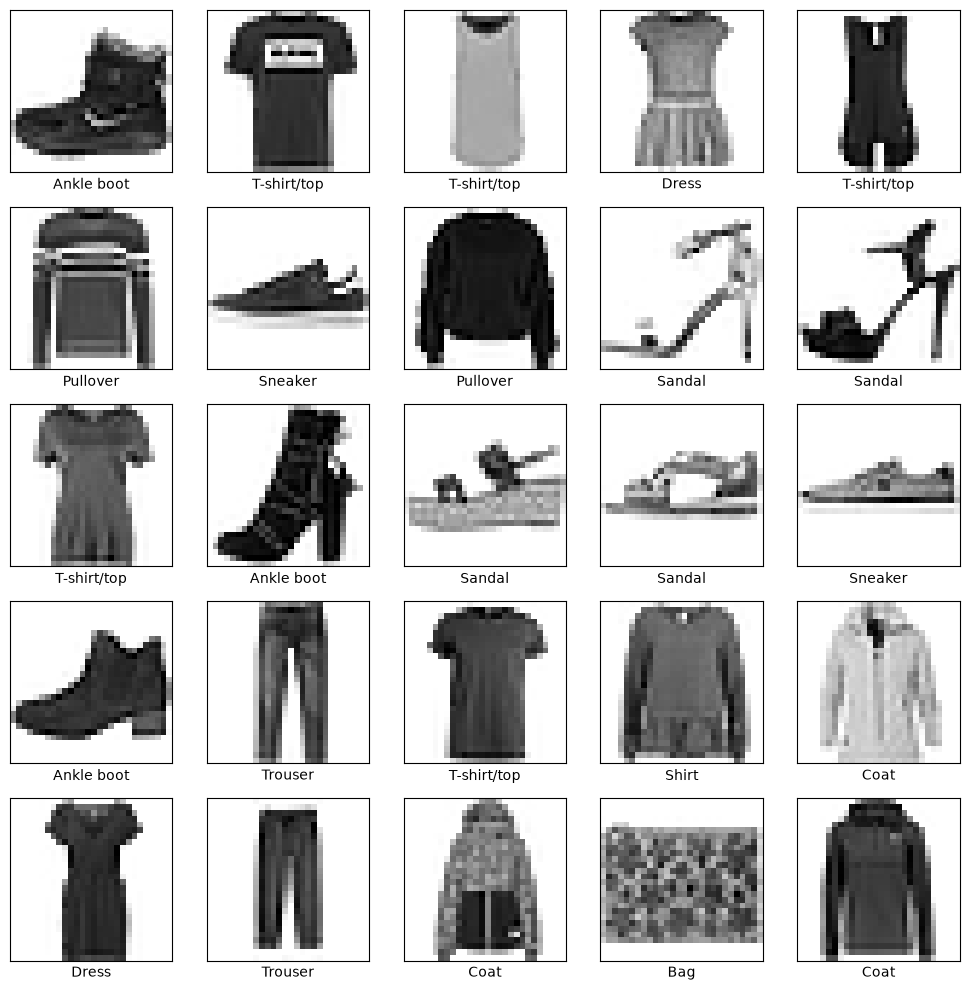



MODEL: Baseline
Activation: relu
Optimiser: adam
Neurons: 128
Epochs: 10
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8235 - loss: 0.4983
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8655 - loss: 0.3758
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8767 - loss: 0.3386
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8850 - loss: 0.3134
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8906 - loss: 0.2950
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8953 - loss: 0.2809
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9011 - loss: 0.2670
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9053 - loss: 0.2584
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9070 - loss: 0.2485
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9097 - loss: 0.2391

Training time: 23.32863426208496 seconds
Te

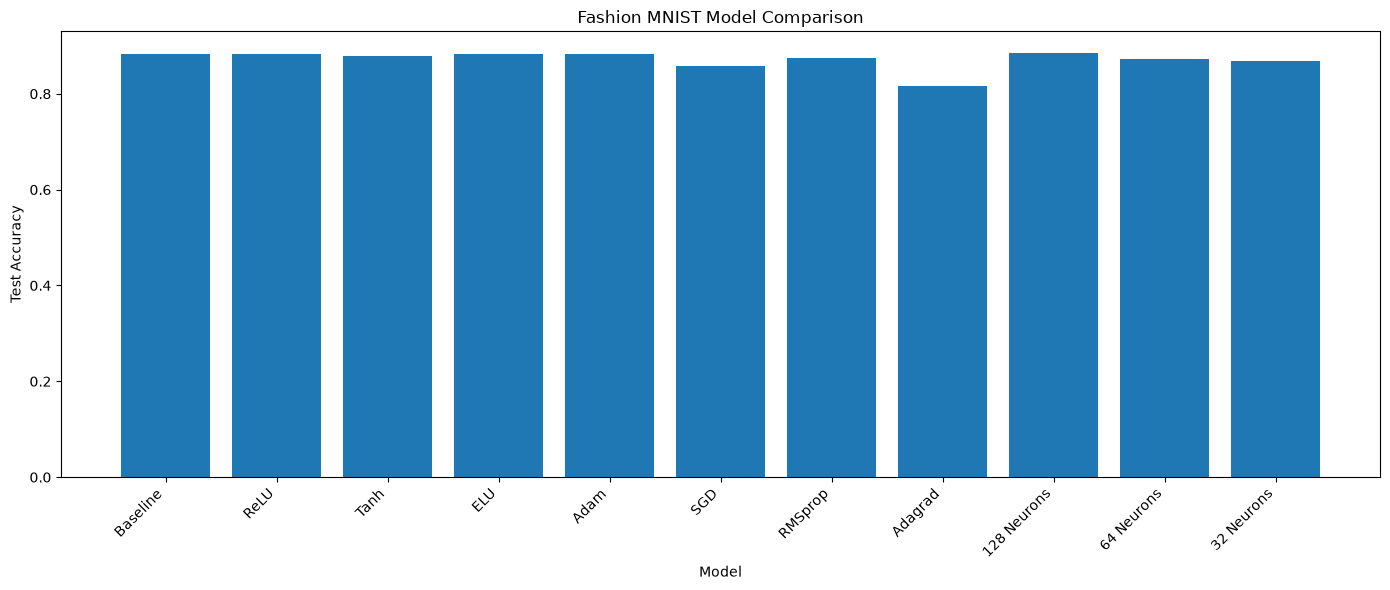

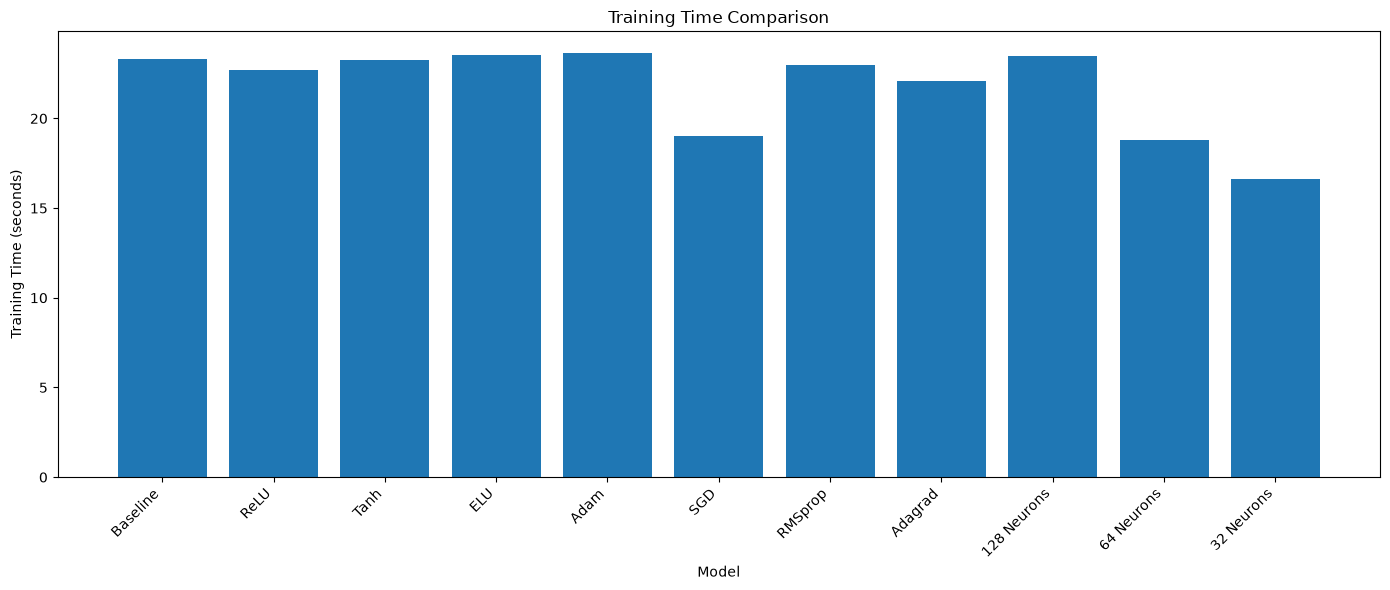


Prediction for first test image:
Predicted: Ankle boot
Actual: Ankle boot
Confidence: 0.9868816


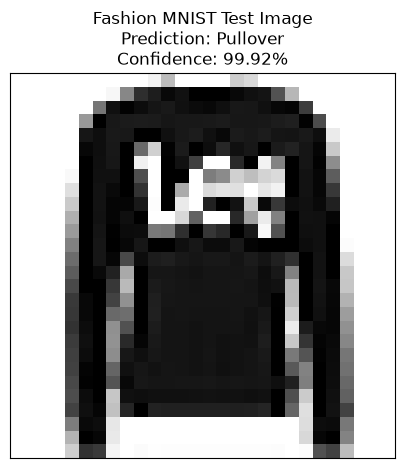

Predicted class: Pullover
Confidence: 99.92%
Actual class: Pullover

Own image loaded successfully.
Original image shape: (51, 66)


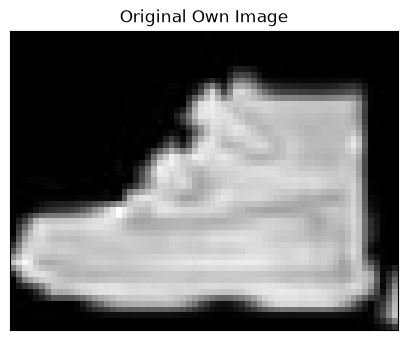

Resized image shape: (28, 28)


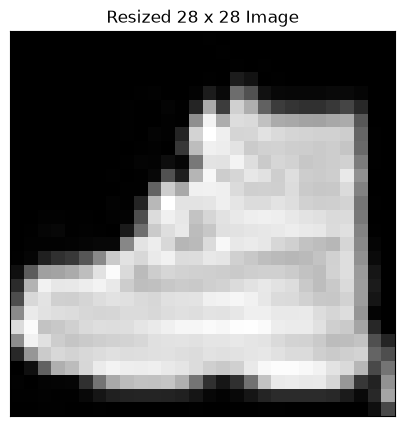

Normalised image shape: (28, 28)
Model input shape: (1, 28, 28)


OWN IMAGE - BASELINE MODEL
Predicted class: Ankle boot
Confidence: 99.07%
Inference time: 0.06818342208862305 seconds


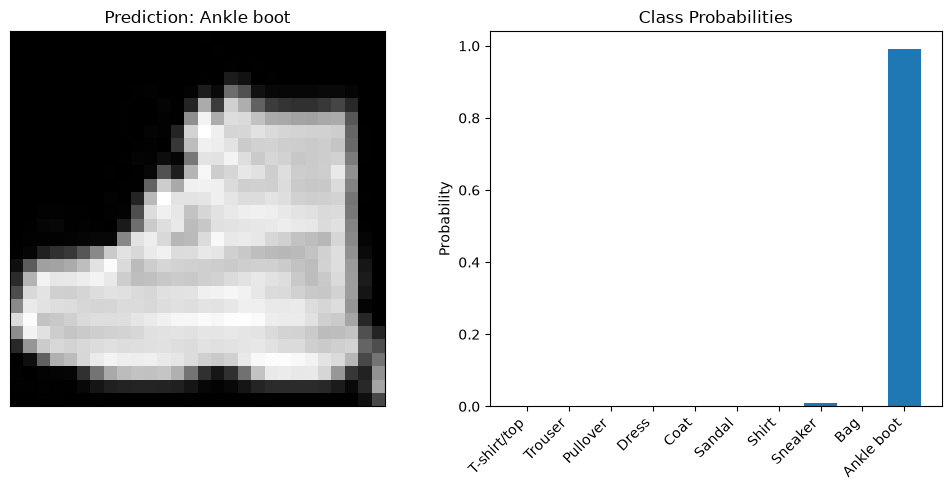



OWN IMAGE - ALL MODEL PREDICTIONS
Model               Prediction          Confidence     Inference Time      
----------------------------------------------------------------------------------------------------
Baseline            Ankle boot          0.9907         0.055921            
ReLU                Ankle boot          0.9989         0.076396            
Tanh                Ankle boot          0.9924         0.080025            
ELU                 Ankle boot          0.8593         0.094961            
Adam                Ankle boot          0.9780         0.085880            
SGD                 Ankle boot          0.9504         0.074510            
RMSprop             Ankle boot          0.9994         0.074657            
Adagrad             Ankle boot          0.8322         0.074379            
128 Neurons         Ankle boot          0.8785         0.076612            
64 Neurons          Ankle boot          0.9957         0.079759            
32 Neurons          Ankle b

In [2]:
# ============================================================
# FASHION MNIST CLASSIFIER - DEPLOYMENT PRACTICAL
# ============================================================
#
# Experiments:
# 1. Baseline: ReLU + Adam + 128 neurons
# 2. Activation functions: ReLU, Tanh, ELU
# 3. Optimisers: Adam, SGD, RMSprop, Adagrad
# 4. Number of neurons: 128, 64, 32
# 5. Test the trained models using your own image
# 6. Compare accuracy, training time and inference time
#
# Dataset:
# Fashion MNIST
#
# Input:
# 28 x 28 grayscale images
#
# Classes:
# 0 = T-shirt/top
# 1 = Trouser
# 2 = Pullover
# 3 = Dress
# 4 = Coat
# 5 = Sandal
# 6 = Shirt
# 7 = Sneaker
# 8 = Bag
# 9 = Ankle boot
# ============================================================


# ============================================================
# 1. INSTALL / IMPORT LIBRARIES
# ============================================================

# If TensorFlow is not already installed, uncomment this:
# !pip install tensorflow

# If OpenCV is not already installed, uncomment this:
# !pip install opencv-python

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import cv2

print("TensorFlow version:", tf.__version__)


# ============================================================
# 2. LOAD FASHION MNIST DATASET
# ============================================================

fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = (
    fashion_mnist.load_data()
)

print("\nTraining images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


# ============================================================
# 3. CLASS NAMES
# ============================================================

class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, "=", name)


# ============================================================
# 4. PREPROCESS THE DATA
# ============================================================
#
# The original notebook scales pixel values from:
#
# 0 - 255
#
# to:
#
# 0 - 1
#
# by dividing by 255.
# ============================================================

train_images = train_images / 255.0
test_images = test_images / 255.0


# ============================================================
# 5. DISPLAY SAMPLE TRAINING IMAGES
# ============================================================

plt.figure(figsize=(10, 10))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(
        train_images[i],
        cmap=plt.cm.binary
    )

    plt.xlabel(class_names[train_labels[i]])

plt.tight_layout()
plt.show()


# ============================================================
# 6. FUNCTION TO CREATE THE MODEL
# ============================================================
#
# This allows us to easily change:
#
# - Activation function
# - Optimiser
# - Number of neurons
#
# while keeping the rest of the model the same.
# ============================================================

def create_model(
    activation='relu',
    optimiser='adam',
    neurons=128
):

    model = tf.keras.Sequential([

        # Convert 28 x 28 image into 784 values
        tf.keras.layers.Flatten(
            input_shape=(28, 28)
        ),

        # Hidden layer
        tf.keras.layers.Dense(
            neurons,
            activation=activation
        ),

        # Output layer - 10 Fashion MNIST classes
        tf.keras.layers.Dense(10)

    ])

    model.compile(

        optimizer=optimiser,

        loss=tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        ),

        metrics=['accuracy']
    )

    return model


# ============================================================
# 7. FUNCTION TO TRAIN AND EVALUATE A MODEL
# ============================================================

def train_and_evaluate(
    name,
    activation='relu',
    optimiser='adam',
    neurons=128,
    epochs=10
):

    print("\n")
    print("=" * 70)
    print("MODEL:", name)
    print("=" * 70)

    print("Activation:", activation)
    print("Optimiser:", optimiser)
    print("Neurons:", neurons)
    print("Epochs:", epochs)

    # Create model
    model = create_model(
        activation=activation,
        optimiser=optimiser,
        neurons=neurons
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    starting_time = time.time()

    history = model.fit(
        train_images,
        train_labels,
        epochs=epochs,
        verbose=1
    )

    training_time = time.time() - starting_time

    # --------------------------------------------------------
    # Test the model
    # --------------------------------------------------------

    test_loss, test_accuracy = model.evaluate(
        test_images,
        test_labels,
        verbose=0
    )

    print("\nTraining time:", training_time, "seconds")
    print("Test loss:", test_loss)
    print("Test accuracy:", test_accuracy)

    # --------------------------------------------------------
    # Create probability model
    # --------------------------------------------------------
    #
    # The original notebook adds Softmax to convert logits
    # into probabilities.
    # --------------------------------------------------------

    probability_model = tf.keras.Sequential([
        model,
        tf.keras.layers.Softmax()
    ])

    return {
        'name': name,
        'model': model,
        'probability_model': probability_model,
        'history': history,
        'activation': activation,
        'optimiser': optimiser,
        'neurons': neurons,
        'training_time': training_time,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy
    }


# ============================================================
# 8. BASELINE MODEL
# ============================================================
#
# Original configuration from the notebook:
#
# ReLU
# Adam
# 128 neurons
# 10 epochs
# ============================================================

baseline = train_and_evaluate(
    name='Baseline',
    activation='relu',
    optimiser='adam',
    neurons=128,
    epochs=10
)


# ============================================================
# 9. ACTIVATION FUNCTION EXPERIMENTS
# ============================================================
#
# Keep:
#
# Optimiser = Adam
# Neurons = 128
#
# Change:
#
# ReLU
# Tanh
# ELU
# ============================================================


# -------------------------
# ReLU
# -------------------------

relu_model = train_and_evaluate(
    name='ReLU',
    activation='relu',
    optimiser='adam',
    neurons=128,
    epochs=10
)


# -------------------------
# Tanh
# -------------------------

tanh_model = train_and_evaluate(
    name='Tanh',
    activation='tanh',
    optimiser='adam',
    neurons=128,
    epochs=10
)


# -------------------------
# ELU
# -------------------------

elu_model = train_and_evaluate(
    name='ELU',
    activation='elu',
    optimiser='adam',
    neurons=128,
    epochs=10
)


# ============================================================
# 10. OPTIMISER EXPERIMENTS
# ============================================================
#
# Keep:
#
# Activation = ReLU
# Neurons = 128
#
# Change:
#
# Adam
# SGD
# RMSprop
# Adagrad
# ============================================================


# -------------------------
# Adam
# -------------------------

adam_model = train_and_evaluate(
    name='Adam',
    activation='relu',
    optimiser='adam',
    neurons=128,
    epochs=10
)


# -------------------------
# SGD
# -------------------------

sgd_model = train_and_evaluate(
    name='SGD',
    activation='relu',
    optimiser='sgd',
    neurons=128,
    epochs=10
)


# -------------------------
# RMSprop
# -------------------------

rmsprop_model = train_and_evaluate(
    name='RMSprop',
    activation='relu',
    optimiser='rmsprop',
    neurons=128,
    epochs=10
)


# -------------------------
# Adagrad
# -------------------------

adagrad_model = train_and_evaluate(
    name='Adagrad',
    activation='relu',
    optimiser='adagrad',
    neurons=128,
    epochs=10
)


# ============================================================
# 11. NUMBER OF NEURONS EXPERIMENT
# ============================================================
#
# Keep:
#
# Activation = ReLU
# Optimiser = Adam
#
# Change:
#
# 128 neurons
# 64 neurons
# 32 neurons
# ============================================================


# -------------------------
# 128 neurons
# -------------------------

neurons_128_model = train_and_evaluate(
    name='128 Neurons',
    activation='relu',
    optimiser='adam',
    neurons=128,
    epochs=10
)


# -------------------------
# 64 neurons
# -------------------------

neurons_64_model = train_and_evaluate(
    name='64 Neurons',
    activation='relu',
    optimiser='adam',
    neurons=64,
    epochs=10
)


# -------------------------
# 32 neurons
# -------------------------

neurons_32_model = train_and_evaluate(
    name='32 Neurons',
    activation='relu',
    optimiser='adam',
    neurons=32,
    epochs=10
)


# ============================================================
# 12. COLLECT ALL RESULTS
# ============================================================

results = [

    baseline,

    # Activation experiments
    relu_model,
    tanh_model,
    elu_model,

    # Optimiser experiments
    adam_model,
    sgd_model,
    rmsprop_model,
    adagrad_model,

    # Neuron experiments
    neurons_128_model,
    neurons_64_model,
    neurons_32_model
]


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

print(
    f"{'Model':<20}"
    f"{'Activation':<15}"
    f"{'Optimiser':<15}"
    f"{'Neurons':<10}"
    f"{'Accuracy':<12}"
    f"{'Training Time':<15}"
)

print("-" * 100)

for result in results:

    print(
        f"{result['name']:<20}"
        f"{result['activation']:<15}"
        f"{result['optimiser']:<15}"
        f"{result['neurons']:<10}"
        f"{result['test_accuracy']:<12.4f}"
        f"{result['training_time']:<15.2f}"
    )


# ============================================================
# 14. FIND BEST MODEL
# ============================================================

best_model_result = max(
    results,
    key=lambda x: x['test_accuracy']
)

print("\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Model:", best_model_result['name'])
print("Activation:", best_model_result['activation'])
print("Optimiser:", best_model_result['optimiser'])
print("Neurons:", best_model_result['neurons'])
print("Test accuracy:", best_model_result['test_accuracy'])
print("Training time:", best_model_result['training_time'])


# ============================================================
# 15. PLOT TEST ACCURACY
# ============================================================

model_names = [
    result['name']
    for result in results
]

accuracies = [
    result['test_accuracy']
    for result in results
]

plt.figure(figsize=(14, 6))

plt.bar(
    model_names,
    accuracies
)

plt.ylabel("Test Accuracy")
plt.xlabel("Model")
plt.title("Fashion MNIST Model Comparison")

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. PLOT TRAINING TIMES
# ============================================================

training_times = [
    result['training_time']
    for result in results
]

plt.figure(figsize=(14, 6))

plt.bar(
    model_names,
    training_times
)

plt.ylabel("Training Time (seconds)")
plt.xlabel("Model")
plt.title("Training Time Comparison")

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. TEST THE BASELINE MODEL ON TEST IMAGES
# ============================================================

probability_model = baseline['probability_model']

predictions = probability_model.predict(
    test_images,
    verbose=0
)

print("\nPrediction for first test image:")

predicted_label = np.argmax(
    predictions[0]
)

print(
    "Predicted:",
    class_names[predicted_label]
)

print(
    "Actual:",
    class_names[test_labels[0]]
)

print(
    "Confidence:",
    np.max(predictions[0])
)


# ============================================================
# 18. FUNCTION TO DISPLAY A PREDICTION
# ============================================================

def display_prediction(
    image,
    probabilities,
    title="Prediction"
):

    predicted_class = np.argmax(probabilities)

    confidence = np.max(probabilities)

    plt.figure(figsize=(6, 5))

    plt.imshow(
        image,
        cmap=plt.cm.binary
    )

    plt.xticks([])
    plt.yticks([])

    plt.title(
        f"{title}\n"
        f"Prediction: {class_names[predicted_class]}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.show()

    print("Predicted class:", class_names[predicted_class])
    print("Confidence:", f"{confidence:.2%}")


# ============================================================
# 19. TEST A SINGLE FASHION MNIST IMAGE
# ============================================================

test_index = 1

single_test_image = test_images[test_index]

single_test_batch = np.expand_dims(
    single_test_image,
    axis=0
)

single_prediction = probability_model.predict(
    single_test_batch,
    verbose=0
)

display_prediction(
    single_test_image,
    single_prediction[0],
    title="Fashion MNIST Test Image"
)

print(
    "Actual class:",
    class_names[test_labels[test_index]]
)


# ============================================================
# 20. OWN IMAGE
# ============================================================
#
# Put your own image in the same folder as the notebook.
#
# The original notebook uses:
#
# boot.jpeg
#
# Change this filename if you use a different image.
# ============================================================

image_path = 'boot.jpeg'


# ============================================================
# 21. LOAD OWN IMAGE
# ============================================================

image = cv2.imread(
    image_path,
    0
)

if image is None:

    raise FileNotFoundError(
        f"Could not find image: {image_path}\n"
        "Make sure the image is in the same folder as the notebook."
    )


print("\nOwn image loaded successfully.")

print(
    "Original image shape:",
    image.shape
)


# ============================================================
# 22. DISPLAY ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(
    image,
    cmap='gray'
)

plt.xticks([])
plt.yticks([])

plt.title("Original Own Image")

plt.show()


# ============================================================
# 23. RESIZE OWN IMAGE TO 28 x 28
# ============================================================

image_resized = cv2.resize(
    image,
    (28, 28)
)

print(
    "Resized image shape:",
    image_resized.shape
)


# ============================================================
# 24. DISPLAY RESIZED IMAGE
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(
    image_resized,
    cmap='gray'
)

plt.xticks([])
plt.yticks([])

plt.title("Resized 28 x 28 Image")

plt.show()


# ============================================================
# 25. NORMALISE OWN IMAGE
# ============================================================
#
# Same preprocessing used for Fashion MNIST:
#
# pixel / 255
# ============================================================

data = np.asarray(
    image_resized
) / 255.0


print(
    "Normalised image shape:",
    data.shape
)


# ============================================================
# 26. ADD BATCH DIMENSION
# ============================================================

img = np.expand_dims(
    data,
    axis=0
)

print(
    "Model input shape:",
    img.shape
)


# ============================================================
# 27. TEST OWN IMAGE USING BASELINE MODEL
# ============================================================

starting_time = time.time()

own_prediction = probability_model.predict(
    img,
    verbose=0
)

inference_time = (
    time.time() - starting_time
)

predicted_class = np.argmax(
    own_prediction[0]
)

confidence = np.max(
    own_prediction[0]
)


print("\n")
print("=" * 70)
print("OWN IMAGE - BASELINE MODEL")
print("=" * 70)

print(
    "Predicted class:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    f"{confidence:.2%}"
)

print(
    "Inference time:",
    inference_time,
    "seconds"
)


# ============================================================
# 28. DISPLAY OWN IMAGE PREDICTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    image_resized,
    cmap='gray'
)

plt.xticks([])
plt.yticks([])

plt.title(
    f"Prediction: {class_names[predicted_class]}"
)


plt.subplot(1, 2, 2)

plt.bar(
    class_names,
    own_prediction[0]
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.ylabel("Probability")

plt.title(
    "Class Probabilities"
)

plt.tight_layout()

plt.show()


# ============================================================
# 29. TEST OWN IMAGE WITH ALL EXPERIMENTAL MODELS
# ============================================================
#
# This allows us to compare how the different models classify
# the same image.
# ============================================================

print("\n")
print("=" * 100)
print("OWN IMAGE - ALL MODEL PREDICTIONS")
print("=" * 100)

print(
    f"{'Model':<20}"
    f"{'Prediction':<20}"
    f"{'Confidence':<15}"
    f"{'Inference Time':<20}"
)

print("-" * 100)


for result in results:

    model_probability = result['probability_model']

    starting_time = time.time()

    prediction = model_probability.predict(
        img,
        verbose=0
    )

    inference_time = (
        time.time() - starting_time
    )

    predicted_class = np.argmax(
        prediction[0]
    )

    confidence = np.max(
        prediction[0]
    )

    print(
        f"{result['name']:<20}"
        f"{class_names[predicted_class]:<20}"
        f"{confidence:<15.4f}"
        f"{inference_time:<20.6f}"
    )


# ============================================================
# 30. COMPARE ACTIVATION FUNCTIONS ON OWN IMAGE
# ============================================================

activation_models = [
    relu_model,
    tanh_model,
    elu_model
]

print("\n")
print("=" * 80)
print("ACTIVATION FUNCTION COMPARISON - OWN IMAGE")
print("=" * 80)

for result in activation_models:

    prediction = result[
        'probability_model'
    ].predict(
        img,
        verbose=0
    )

    predicted_class = np.argmax(
        prediction[0]
    )

    confidence = np.max(
        prediction[0]
    )

    print(
        result['activation'],
        "->",
        class_names[predicted_class],
        "| Confidence:",
        f"{confidence:.2%}"
    )


# ============================================================
# 31. COMPARE OPTIMISERS ON OWN IMAGE
# ============================================================

optimiser_models = [
    adam_model,
    sgd_model,
    rmsprop_model,
    adagrad_model
]

print("\n")
print("=" * 80)
print("OPTIMISER COMPARISON - OWN IMAGE")
print("=" * 80)

for result in optimiser_models:

    prediction = result[
        'probability_model'
    ].predict(
        img,
        verbose=0
    )

    predicted_class = np.argmax(
        prediction[0]
    )

    confidence = np.max(
        prediction[0]
    )

    print(
        result['optimiser'],
        "->",
        class_names[predicted_class],
        "| Confidence:",
        f"{confidence:.2%}"
    )


# ============================================================
# 32. COMPARE NUMBER OF NEURONS ON OWN IMAGE
# ============================================================

neuron_models = [
    neurons_128_model,
    neurons_64_model,
    neurons_32_model
]

print("\n")
print("=" * 80)
print("NEURON COMPARISON - OWN IMAGE")
print("=" * 80)

for result in neuron_models:

    prediction = result[
        'probability_model'
    ].predict(
        img,
        verbose=0
    )

    predicted_class = np.argmax(
        prediction[0]
    )

    confidence = np.max(
        prediction[0]
    )

    print(
        result['neurons'],
        "neurons ->",
        class_names[predicted_class],
        "| Confidence:",
        f"{confidence:.2%}"
    )


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("PRACTICAL ACTIVITY COMPLETE")
print("=" * 100)

print("\nYou have tested:")

print("1. ReLU, Tanh and ELU activation functions")
print("2. Adam, SGD, RMSprop and Adagrad optimisers")
print("3. 128, 64 and 32 neurons")
print("4. Test-set accuracy")
print("5. Training time")
print("6. Inference time")
print("7. Your own image")
print("8. Prediction confidence")

print("\nBest model based on test accuracy:")

print(
    best_model_result['name']
)

print(
    "Accuracy:",
    f"{best_model_result['test_accuracy']:.2%}"
)

print(
    "Activation:",
    best_model_result['activation']
)

print(
    "Optimiser:",
    best_model_result['optimiser']
)

print(
    "Neurons:",
    best_model_result['neurons']
)